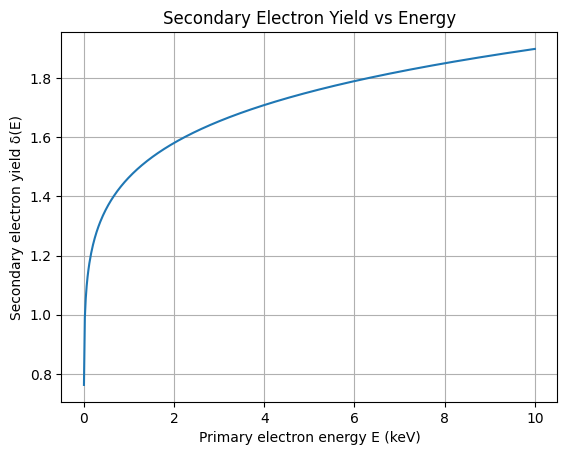

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -------- Material parameters (example: Aluminum oxide) --------
E_max = 0.25      # keV
delta_max = 0.92
A = 0.1460
B = 0.0250
C = 0.3440

# -------- Energy range --------
E = np.linspace(0.001, 10, 500)  # keV

# -------- Secondary electron yield formula --------
delta = delta_max * (E / E_max)**A * np.exp(
    A * (1 - (E / E_max)**B)
) + C

# -------- Plot --------
plt.figure()
plt.plot(E, delta)
plt.xlabel("Primary electron energy E (keV)")
plt.ylabel("Secondary electron yield δ(E)")
plt.title("Secondary Electron Yield vs Energy")
plt.grid(True)
plt.show()

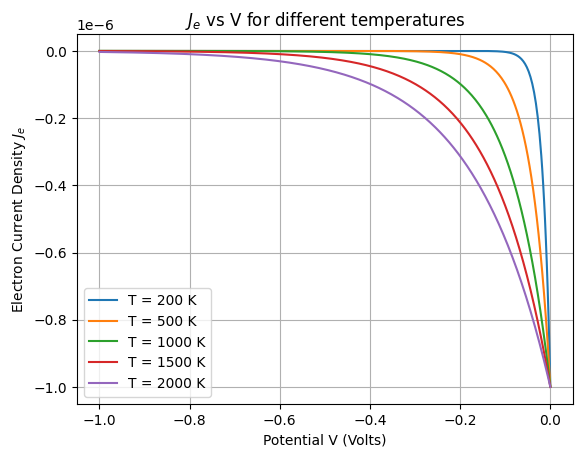

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import elementary_charge, e, k


#e = 1.602e-19
#k = 1.381e-23
J0e = 1e-6
mi = 1.67e-27
ne = 1e15

V=np.linspace(-1, 0, 500)
T= [200, 500, 1000, 1500, 2000]

plt.figure()

def compute_Je(temp,V,J0):
  '''
  This function computes the electron current density given potential and temperature.
  REF: XXX
  Input:
  temp: Temperature of the medium
  V: Potential of the spacecraft
  J0: Initial current density
  Output:
  Je: Electron current density
  '''

  Je = -J0*np.exp(e*V/(k*temp))
  return Je


for t in T:
    Je = compute_Je(t,V,J0e)
    plt.plot(V, Je, label=f"T = {t} K")

plt.xlabel("Potential V (Volts)")
plt.ylabel("Electron Current Density $J_e$")
plt.title("$J_e$ vs V for different temperatures")
plt.legend()
plt.grid(True)

plt.show()





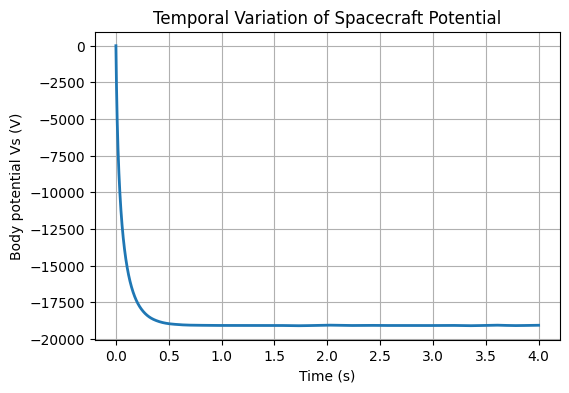

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constants

e = 1.602e-19
k = 1.38e-23

# Spacecraft parameters
A = 72.0                      # m^2
C = 328.76e-12               # F

# Plasma parameters
ne = ni = 1.25e6             # m^-3

Te_eV = 7.5e3                # eV
Ti_eV = 10e3                   # eV

Te = Te_eV * e / k           # Kelvin
Ti = Ti_eV * e / k

me = 9.11e-31
mi = 1.67e-27                # proton mass

K_star = 1 / np.sqrt(2 * np.pi)

# Thermal currents (write as function, ne Te as inputs )
#define function

j0e = K_star * e * ne * np.sqrt(k * Te / me)
j0i = K_star * e * ni * np.sqrt(k * Ti / mi)

# Safe exponential

def safe_exp(x):
    return np.exp(np.clip(x, -50, 50)) #this is to keep exponential in the range and not to blow up(but the terms inside exp is always very tiny as i noticed)


# Electron current

def j_e(Vs):

        return j0e * safe_exp(-e *abs(Vs) / (k * Te))



# Ion current

def j_i(Vs):
    return j0i * (1 + e * abs(Vs) / (k * Ti))


# Differential equation

def dVs_dt(Vs):
    return (A / C) * (j_i(Vs) - j_e(Vs))




#using scipy
from scipy.integrate import solve_ivp

def solve_spacecraft_potential(V0, t_max, dt):

    # Time points where we want the solution returned
    t_eval = np.arange(0, t_max, dt)

    # solve_ivp expects function as f(t, y)
    def rhs(t, V):
        return dVs_dt(V[0])

    sol = solve_ivp(
        rhs,
        t_span=(0, t_max),
        y0=[V0],
        method='RK45',
        t_eval=t_eval
    )

    return sol.t, sol.y[0]
    from scipy.integrate import solve_ivp

def solve_spacecraft_potential(V0, t_max, dt):

    # Time points where you want the solution returned
    t_eval = np.arange(0, t_max, dt)

    # solve_ivp expects function as f(t, y)
    def rhs(t, V):
        return dVs_dt(V[0])

    sol = solve_ivp(
        rhs,
        t_span=(0, t_max),
        y0=[V0],
        method='RK45',
        t_eval=t_eval
    )

    return sol.t, sol.y[0]
    # Initial condition
V0 = 0.0

# Solve using SciPy RK45
t, V = solve_spacecraft_potential(V0, t_max=4.0, dt=1e-6)

# Plot
plt.figure(figsize=(6,4))
plt.plot(t, V, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Body potential Vs (V)")
plt.title("Temporal Variation of Spacecraft Potential")
plt.grid()
plt.show()




#to find the steady state value of V_s


tolerance = 0.0001

Vs_steady = None
time_steady = None

# Skip initial points to avoid false detection at t=0
for i in range(10, len(V)):
    if abs(dVs_dt(V[i])) < tolerance:
        Vs_steady = V[i]
        time_steady = t[i]
        break

if Vs_steady is not None:
    print("Steady state Vs ≈", Vs_steady)
    print("Time at steady state ≈", time_steady, "seconds")
else:
    print("No steady state found")

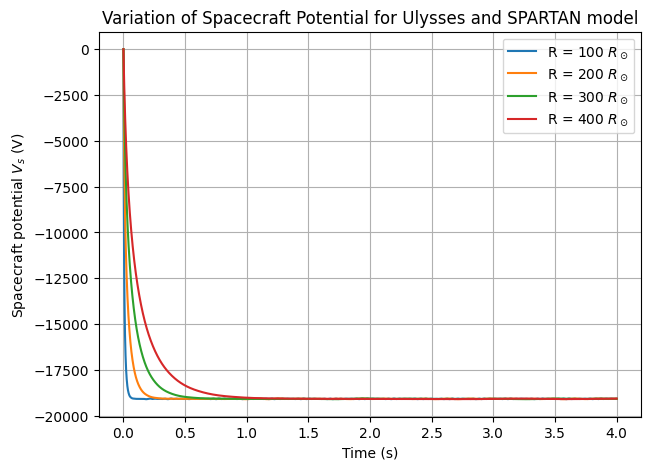

In [ ]:
#spacecarft charging for various models of space plasma

# model 1 : Ulysses and SPARTAN model

## Assuming the electron density equals to ion denisty in this model

import numpy as np
import matplotlib.pyplot as plt

def electron_density(R):
    '''
    This function computes the electron density at a specific solar radius.

    REF: https://iopscience.iop.org/article/10.1086/522227/pdf

    Input:
        R : distance from the Sun in units of solar radii

    Output:
        ne : electron density in m^-3
    '''
    ne = (
        1.155e11 * R**(-2)
        + 32.3e11 * R**(-4.39)
        + 3254e11 * R**(-16.25)
    )

    return ne

# Following are the necessary plasma parameters required for final calculation of spacecraft potential

# Constants

e = 1.602e-19
k = 1.38e-23

# Spacecraft parameters
A = 72.0                      # m^2
C = 328.76e-12               # F

#Temperature of plasma

Te_eV = 7.5e3      # eV
Ti_eV = 10e3       # eV

Te = Te_eV * e / k # in Kelvin
Ti = Ti_eV * e / k #in kelvin

me = 9.11e-31      #electron mass
mi = 1.67e-27      # proton mass

K_star = 1 / np.sqrt(2 * np.pi)

# Electron and ion thermal current densities
def j0e(ne):
    '''
    Electron thermal current density [A/m^2]
    '''
    return K_star * e * ne * np.sqrt(k * Te / me)


def j0i(ne):
    '''
    Ion thermal current density [A/m^2]
    '''
    return K_star * e * ne * np.sqrt(k * Ti / mi)


# Safe exponential to avoid overflow
def safe_exp(x):
    '''
    Restrict exponent to avoid overflow in np.exp
    '''
    return np.exp(np.clip(x, -50, 50))


# Electron current density as a function of spacecraft potential Vs
def j_e(Vs, ne):
    '''
    Electron current density [A/m^2]

    Input:
        Vs : spacecraft potential [V]
        ne : electron density [m^-3]
    '''
    j0e_val = j0e(ne)
    return j0e_val * safe_exp(-e * abs(Vs) / (k * Te))


# Ion current density as a function of spacecraft potential Vs
def j_i(Vs, ne):
    '''
    Ion current density [A/m^2]

    Input:
        Vs : spacecraft potential [V]
        ni=ne : ion density [m^-3]
    '''
    j0i_val = j0i(ne)
    return j0i_val * (1 + e * abs(Vs) / (k * Ti))

# Differential equation for spacecraft potential
def dVs_dt(Vs, ne):
    return (A / C) * (j_i(Vs, ne) - j_e(Vs, ne))

from scipy.integrate import solve_ivp

def solve_spacecraft_potential(V0, ne, t_max, dt):
    '''
    Solve dVs/dt = (A/C) [j_i(Vs) - j_e(Vs)]

    Input:
        V0    : initial spacecraft potential [V]
        ne    : plasma density [m^-3]
        t_max : final time [s]
        dt    : output timestep [s]
    '''

    t_eval = np.arange(0, t_max, dt)

    def rhs(t, V):
        return [dVs_dt(V[0], ne)]

    sol = solve_ivp(
        rhs,
        t_span=(0, t_max),
        y0=[V0],
        method='RK45',
        t_eval=t_eval
    )

    return sol.t, sol.y[0]

# Values of R (in solar radii) you want to compare
R_values = [100, 200,300, 400]

plt.figure(figsize=(7,5))

for R in R_values:

    # Electron/ion density at this solar radius
    ne = electron_density(R)

    # Solve spacecraft potential
    t, V = solve_spacecraft_potential(V0=0.0, ne=ne, t_max=4.0, dt=1e-5)

    # Plot
    plt.plot(t, V, label=f"R = {R} $R_\\odot$")

plt.xlabel("Time (s)")
plt.ylabel("Spacecraft potential $V_s$ (V)")
plt.title("Variation of Spacecraft Potential for Ulysses and SPARTAN model")
plt.grid(True)
plt.legend()
plt.show()



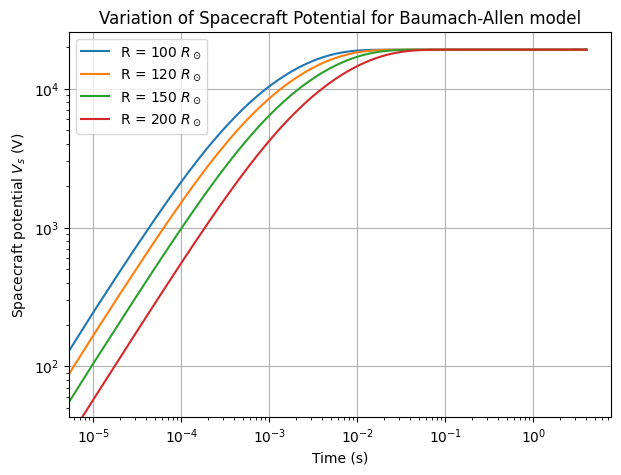

In [ ]:
# model 2 : Baumach - Allen Model

## Assuming the electron density equals to ion denisty in this model

import numpy as np
import matplotlib.pyplot as plt

def electron_density(R):
    '''
    This function computes the electron density at a specific solar radius.

    REF: https://iopscience.iop.org/article/10.1086/522227/pdf

    Input:
        R : distance from the Sun in units of solar radii

    Output:
        ne : electron density in m^-3
    '''
    ne = (
        2.99e14 * R**(-16)
        + 1.5e14 * R**(-6)
        + 4.1e11 *( R**(-2)
        + 5.74 * R**(-2.7))
    )

    return ne

# Following are the necessary plasma parameters required for final calculation of spacecraft potential

# Constants

e = 1.602e-19
k = 1.38e-23

# Spacecraft parameters
A = 72.0                      # m^2
C = 328.76e-12               # F

#Temperature of plasma

Te_eV = 7.5e3      # eV
Ti_eV = 10e3       # eV

Te = Te_eV * e / k # in Kelvin
Ti = Ti_eV * e / k #in kelvin

me = 9.11e-31      #electron mass
mi = 1.67e-27      # proton mass

K_star = 1 / np.sqrt(2 * np.pi)

# Electron and ion thermal current densities
def j0e(ne):
    '''
    Electron thermal current density [A/m^2]
    '''
    return K_star * e * ne * np.sqrt(k * Te / me)


def j0i(ne):
    '''
    Ion thermal current density [A/m^2]
    '''
    return K_star * e * ne * np.sqrt(k * Ti / mi)


# Safe exponential to avoid overflow
def safe_exp(x):
    '''
    Restrict exponent to avoid overflow in np.exp
    '''
    return np.exp(np.clip(x, -50, 50))


# Electron current density as a function of spacecraft potential Vs
def j_e(Vs, ne):
    '''
    Electron current density [A/m^2]

    Input:
        Vs : spacecraft potential [V]
        ne : electron density [m^-3]
    '''
    j0e_val = j0e(ne)
    return j0e_val * safe_exp(-e * abs(Vs) / (k * Te))


# Ion current density as a function of spacecraft potential Vs
def j_i(Vs, ne):
    '''
    Ion current density [A/m^2]

    Input:
        Vs : spacecraft potential [V]
        ni=ne : ion density [m^-3]
    '''
    j0i_val = j0i(ne)
    return j0i_val * (1 + e * abs(Vs) / (k * Ti))

# Differential equation for spacecraft potential
def dVs_dt(Vs, ne):
    return (A / C) * (j_i(Vs, ne) - j_e(Vs, ne))

from scipy.integrate import solve_ivp

def solve_spacecraft_potential(V0, ne, t_max, dt):
    '''
    Solve dVs/dt = (A/C) [j_i(Vs) - j_e(Vs)]

    Input:
        V0    : initial spacecraft potential [V]
        ne    : plasma density [m^-3]
        t_max : final time [s]
        dt    : output timestep [s]
    '''

    t_eval = np.arange(0, t_max, dt)

    def rhs(t, V):
        return [dVs_dt(V[0], ne)]

    sol = solve_ivp(
        rhs,
        t_span=(0, t_max),
        y0=[V0],
        method='RK45',
        t_eval=t_eval
    )

    return sol.t, sol.y[0]

# Values of R (in solar radii) you want to compare
R_values = [100,120,150,200]

plt.figure(figsize=(7,5))

for R in R_values:

    # Electron/ion density at this solar radius
    ne = electron_density(R)

    # Solve spacecraft potential
    t, V = solve_spacecraft_potential(V0=0.0, ne=ne, t_max=4.0, dt=1e-5)

    # Plot
    plt.plot(t, abs(V), label=f"R = {R} $R_\\odot$")

plt.xlabel("Time (s)")
plt.ylabel("Spacecraft potential $V_s$ (V)")
plt.title("Variation of Spacecraft Potential for Baumach-Allen model")
plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()


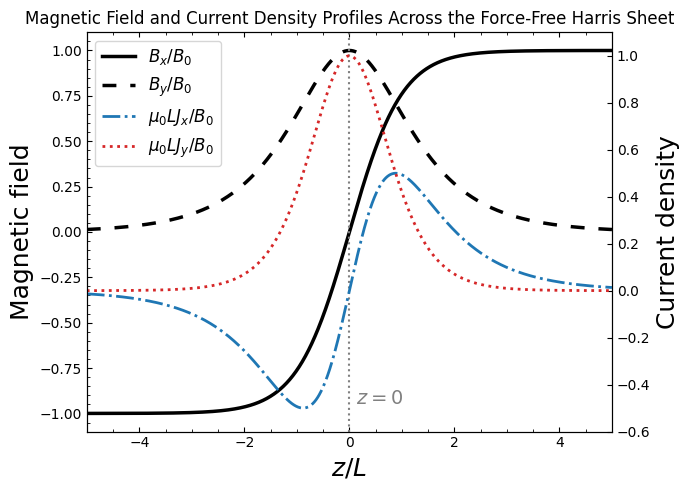

In [ ]:
# model 3 : Magnetic reconnection Model


import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dimensionless coordinate
zL = np.linspace(-5, 5, 1000)

# Magnetic field components (normalized by B0)
Bx = np.tanh(zL)
By = 1 / np.cosh(zL)

# Current density components normalized by (B0 / μ0 L)
Jx = np.sinh(zL) / np.cosh(zL)**2
Jy = 1 / np.cosh(zL)**2

fig, ax1 = plt.subplots(figsize=(7,5))

# Magnetic fields on left axis
ax1.plot(zL, Bx, 'k-', lw=2.5, label=r'$B_x/B_0$')
ax1.plot(zL, By, 'k--', lw=2.5, dashes=(4,4), label=r'$B_y/B_0$')
ax1.set_xlabel(r'$z/L$', fontsize=18)
ax1.set_ylabel('Magnetic field', fontsize=18)
ax1.set_xlim(-5,5)
ax1.set_ylim(-1.1,1.1)

# Mark current sheet center
ax1.axvline(0, color='gray', linestyle=':', lw=1.5)
ax1.text(0.12, -0.95, r'$z=0$', fontsize=14, color='gray')

# Second y-axis for current density
ax2 = ax1.twinx()
ax2.plot(zL, Jx, color='tab:blue', lw=2, linestyle='-.',
         label=r'$\mu_0 L J_x/B_0$')
ax2.plot(zL, Jy, color='tab:red', lw=2, linestyle=':',
         label=r'$\mu_0 L J_y/B_0$')
ax2.set_ylabel('Current density', fontsize=18)
ax2.set_ylim(-0.6, 1.1)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=12)

ax1.minorticks_on()
ax1.tick_params(direction='in', which='both', top=True, right=False)
ax2.tick_params(direction='in', which='both')
plt.title("Magnetic Field and Current Density Profiles Across the Force-Free Harris Sheet")
plt.tight_layout()
plt.show()





In [ ]:
# Magnetic reconnection model

import numpy as np

# Physical constants
qe = -1.602176634e-19      # Electron charge [C]
qi =  1.602176634e-19      # Ion charge [C]
me = 9.10938356e-31        # Electron mass [kg]
mp = 1.6726219e-27         # Proton mass [kg]
kB = 1.380649e-23          # Boltzmann constant [J/K]


def thermal_speed(T, m):
    """
    Thermal speed v_th = sqrt(k_B T / m)

    Parameters
    ----------
    T : float
        Temperature in Kelvin.
    m : float
        Particle mass [kg].
    """
    return np.sqrt(kB * T / m)


# ---------------------------------------------------------------------
# Force-free Harris-sheet vector potentials
# ---------------------------------------------------------------------
def A_x(z, B0, L):
    """
    Vector potential A_x(z) for the force-free Harris sheet.

    A_x = B0 * L * arctan[sinh(z/L)]
    """
    return B0 * L * np.arctan(np.sinh(z / L))



def A_y(z, B0, L):
    """
    Vector potential A_y(z) for the force-free Harris sheet.

    A_y = -B0 * L * ln[cosh(z/L)]
    """
    return -B0 * L * np.log(np.cosh(z / L))


# ---------------------------------------------------------------------
# Electron distribution function
# ---------------------------------------------------------------------
def F_e(vx, vy, vz, z,
        n0, Te, u0, b, B0, L,
        phi=0.0,
        q=qe,
        m=me):
    """
    Electron distribution function for the force-free Harris sheet.

    Parameters
    ----------
    vx, vy, vz : float or ndarray
        Velocity components [m/s]
    z : float
        Position across the current sheet [m]
    n0 : float
        Reference density [m^-3]
    Te : float
        Electron temperature [K]
    u0 : float
        Drift speed parameter [m/s]
    b : float
        Dimensionless background parameter (> 1/2)
    B0 : float
        Magnetic field amplitude [T]
    L : float
        Sheet half-thickness [m]
    phi : float, optional
        Electrostatic potential [V]
    """

    beta = 1.0 / (kB * Te)
    vth = thermal_speed(Te, m)

    # Local vector potentials
    Ax = A_x(z, B0, L)
    Ay = A_y(z, B0, L)

    # Canonical momenta
    px = m * vx + q * Ax
    py = m * vy + q * Ay

    # Single-particle Hamiltonian
    H = 0.5 * m * (vx**2 + vy**2 + vz**2) + q * phi

    prefactor = (
        n0
        / ((1.0 + b) * (np.sqrt(2.0 * np.pi) * vth)**3)
    )

    bracket = (
        b
        - 0.5 * np.exp(beta * m * u0**2 / 2.0)
          * np.cos(beta * u0 * px)
        + np.exp(beta * m * u0**2 / 2.0)
          * np.exp(beta * u0 * py)
    )

    return prefactor * np.exp(-beta * H) * bracket


# ---------------------------------------------------------------------
# Ion distribution function
# ---------------------------------------------------------------------
def F_i(vx, vy, vz,
        n0_i, Ti,
        phi=0.0,
        q=qi,
        m=mp):
    """
    Ion distribution function (Maxwellian).

    Parameters
    ----------
    vx, vy, vz : float or ndarray
        Velocity components [m/s]
    n0_i : float
        Ion density [m^-3]
    Ti : float
        Ion temperature [K]
    phi : float, optional
        Electrostatic potential [V]
    """

    beta = 1.0 / (kB * Ti)
    vth = thermal_speed(Ti, m)

    H = 0.5 * m * (vx**2 + vy**2 + vz**2) + q * phi

    prefactor = n0_i / ((np.sqrt(2.0 * np.pi) * vth)**3)

    return prefactor * np.exp(-beta * H)


 # Ask user for temperatures
    Te = float(input("Enter electron temperature Te [K]: "))
    Ti = float(input("Enter ion temperature Ti [K]: "))



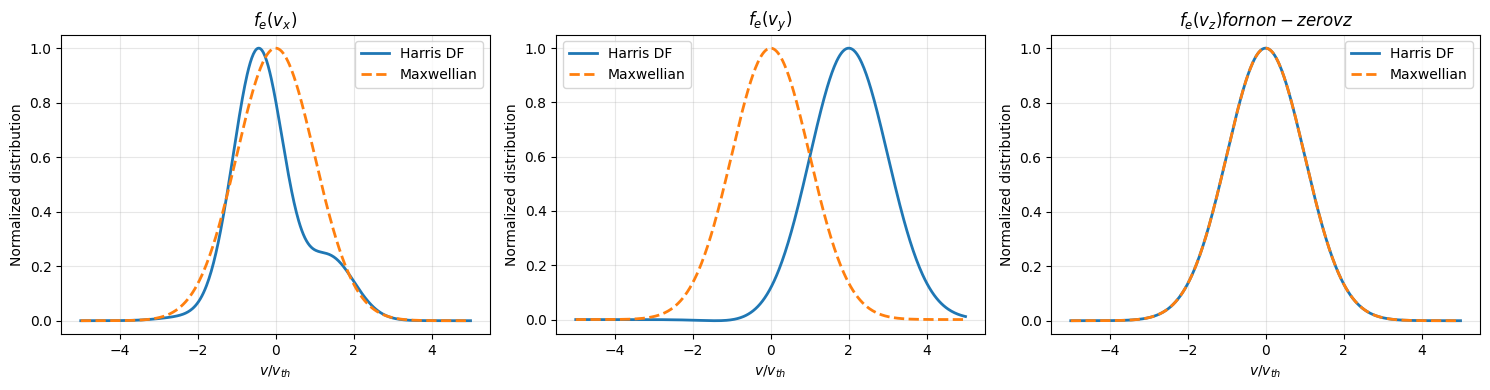

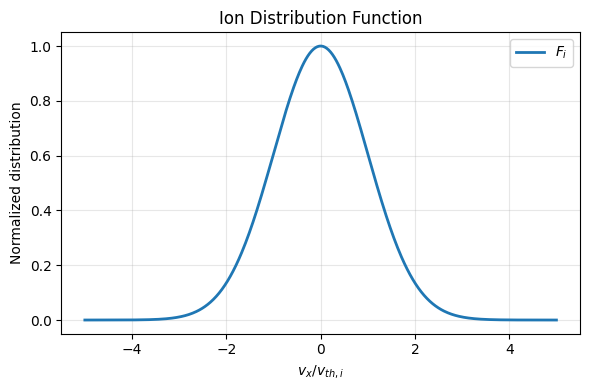

jx_e = -5.110354477919832e-14
jy_e = -7.66080538161838e-12
jx_i = 2.546479106222058e-08
jy_i = 2.5464791062220578e-08
jx_e   = -5.110354477919832e-14
jx_i   = 2.546479106222058e-08
jx_net = 2.5464739958675803e-08
jy_e   = -7.66080538161838e-12
jy_i   = 2.5464791062220578e-08
jy_net = 2.545713025683896e-08


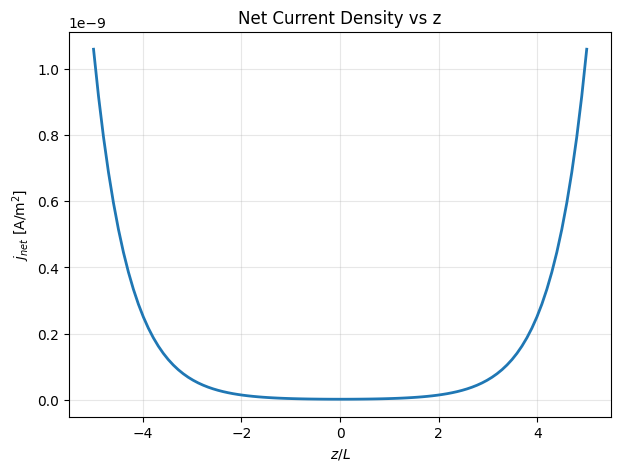

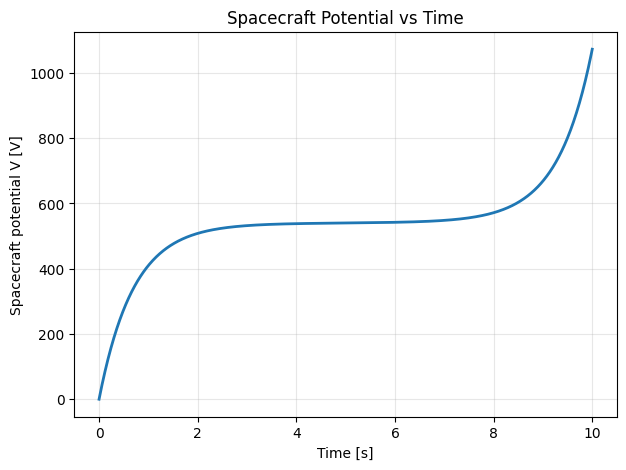

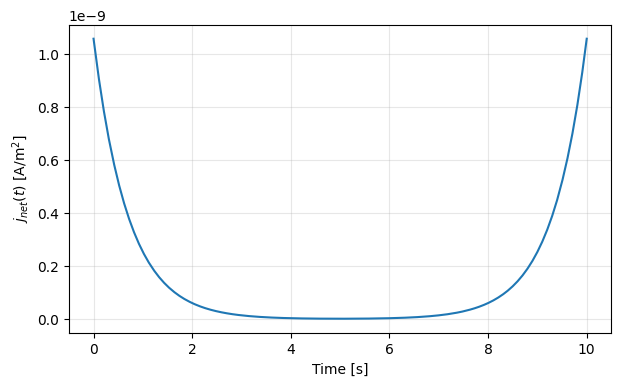

In [2]:
# ==========================================================
# SIMPLE DEMONSTRATION OF THE FORCE-FREE HARRIS ELECTRON DF
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 1. Physical constants
# ----------------------------------------------------------
kB = 1.38e-23              # Boltzmann constant [J/K]
me = 9.11e-31              # electron mass [kg]
qe = -1.60e-19             # electron charge [C]

# ----------------------------------------------------------
# 2. Choose plasma parameters
# ----------------------------------------------------------
Te = 1.0e5                # electron temperature [K]
n0 = 1.0e12              # use normalized density

# electron thermal speed
vth = np.sqrt(kB * Te / me)

# ----------------------------------------------------------
# 3. Choose Harris-sheet parameters
# (intentionally exaggerated so the effect is visible)
# ----------------------------------------------------------
u0 = 2.0 * vth            # drift speed
b  = 0.1

# We only want to see the effect of px and py,
# so choose simple values of the vector potentials
# ----------------------------------------------------------
# Harris-sheet magnetic parameters
# ----------------------------------------------------------
B0 = 5e-6          # magnetic field [T]
L  = 1.0           # current-sheet scale length
z  = 1.5 * L    # choose a position in the sheet

# ----------------------------------------------------------
# Vector potentials of the force-free Harris sheet
# ----------------------------------------------------------
Ax = B0 * L * np.arctan(np.sinh(z / L))

Ay = -B0 * L * np.log(np.cosh(z / L))

beta = 1.0 / (kB * Te)

# ----------------------------------------------------------
# 4. Velocity axis
# ----------------------------------------------------------
v = np.linspace(-5*vth, 5*vth, 500)

# ----------------------------------------------------------
# 5. Maxwellian distribution
# ----------------------------------------------------------
fM = np.exp(-v**2 / (2*vth**2))

# ----------------------------------------------------------
# 6. Harris DF in vx direction
# Here py = 0, vz = 0
# ----------------------------------------------------------
px = me*v + qe*Ax

fx = np.exp(-v**2/(2*vth**2)) * (
    b
    - 0.5*np.exp(beta*me*u0**2/2.0)*np.cos(beta*u0*px)
    + np.exp(beta*me*u0**2/2.0)
)

# normalize
fx = fx / np.max(fx)

# ----------------------------------------------------------
# 7. Harris DF in vy direction
# Here px = 0, vz = 0
# ----------------------------------------------------------
py = me*v + qe*Ay

fy = np.exp(-v**2/(2*vth**2)) * (
    b
    - 0.5*np.exp(beta*me*u0**2/2.0)
    + np.exp(beta*me*u0**2/2.0) * np.exp(beta*u0*py)
)

# normalize
fy = fy / np.max(fy)

# ----------------------------------------------------------
# 8. vz direction: should remain Maxwellian-like
# ----------------------------------------------------------
fz = np.exp(-v**2/(2*vth**2))
fz = fz / np.max(fz)

# normalize Maxwellian
fM = fM / np.max(fM)

# ----------------------------------------------------------
# 9. Plot
# ----------------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

# vx
ax[0].plot(v/vth, fx, lw=2, label='Harris DF')
ax[0].plot(v/vth, fM, '--', lw=2, label='Maxwellian')
ax[0].set_title(r'$f_e(v_x)$')

# vy
ax[1].plot(v/vth, fy, lw=2, label='Harris DF')
ax[1].plot(v/vth, fM, '--', lw=2, label='Maxwellian')
ax[1].set_title(r'$f_e(v_y)$')

# vz
ax[2].plot(v/vth, fz, lw=2, label='Harris DF')
ax[2].plot(v/vth, fM, '--', lw=2, label='Maxwellian')
ax[2].set_title(r'$f_e(v_z) for non-zero vz$')

for a in ax:
    a.set_xlabel(r'$v/v_{th}$')
    a.set_ylabel('Normalized distribution')
    a.grid(alpha=0.3)
    a.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Ion distribution function
# ----------------------------------------------------------

mi = 1.67e-27          # ion mass [kg]
qi = 1.60e-19          # ion charge [C]  (proton)
n0_i = 1.0e12

# use same temperature as electrons
beta_i = beta
vth_i = np.sqrt(kB * Te / mi)

# choose an electrostatic potential
phi = 0.0              # [V]

# velocity grid
v = np.linspace(-5*vth_i, 5*vth_i, 500)

# take a 1D slice through velocity space:
# vy = vz = 0, vx = v
vx = v
vy = 0.0
vz = 0.0

# total speed squared
v2 = vx**2 + vy**2 + vz**2

# ion Hamiltonian
Hi = 0.5 * mi * v2 + qi * phi

# ion distribution function
Fi = (n0_i / ((np.sqrt(2*np.pi) * vth_i)**3)) * np.exp(-beta_i * Hi)

# normalize for plotting
Fi_norm = Fi / np.max(Fi)

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------
plt.figure(figsize=(6,4))
plt.plot(vx / vth_i, Fi_norm, lw=2, label=r'$F_i$')

plt.xlabel(r'$v_x/v_{th,i}$')
plt.ylabel('Normalized distribution')
plt.title(r'Ion Distribution Function')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# Evaluate electron current densities jx_e and jy_e
# by integrating q_e * v * F_e dv
# with vy = vz = 0
# ----------------------------------------------------------

from scipy.integrate import simpson

# integration range
vx = np.linspace(0.0, 10.0*vth, 2000)

# set vy = vz = 0
vy0 = 0.0
vz0 = 0.0

# canonical momenta for this 1D slice
px = me*vx + qe*Ax
py = qe*Ay                      # since vy = 0

# Full electron DF for jx_e
Fe_x = (n0 / ((np.sqrt(2*np.pi)*vth)**3)) * np.exp(
    -beta * (
        0.5*me*(vx**2 + vy0**2 + vz0**2)
    )
) * (
    b
    - 0.5*np.exp(beta*me*u0**2/2.0)*np.cos(beta*u0*px)
    + np.exp(beta*me*u0**2/2.0)
)

# integrand q_e * vx * F_e
integrand_jx = qe * vx * Fe_x

# numerical integral
jx_e = simpson(integrand_jx, x=vx)

print("jx_e =", jx_e)
# ----------------------------------------------------------
# Evaluate jy_e
# ----------------------------------------------------------

vy = np.linspace(0.0, 10.0*vth, 2000)

vx0 = 0.0
vz0 = 0.0

# canonical momentum in y
py = me*vy + qe*Ay

# electron DF for y direction
Fe_y = (n0 / ((np.sqrt(2*np.pi)*vth)**3)) * np.exp(
    -beta * (
        0.5*me*(vx0**2 + vy**2 + vz0**2)
    )
) * (
    b
    - 0.5*np.exp(beta*me*u0**2/2.0)
    + np.exp(beta*me*u0**2/2.0) * np.exp(beta*u0*py)
)

# integrand q_e * vy * F_e
integrand_jy = qe * vy * Fe_y

# numerical integral
jy_e = simpson(integrand_jy, x=vy)

print("jy_e =", jy_e)

from scipy.integrate import simpson

# velocity grid
Nv = 400
vx = np.linspace(0.0, 10.0*vth_i, Nv)
vy = np.linspace(-10.0*vth_i, 10.0*vth_i, Nv)

VX, VY = np.meshgrid(vx, vy, indexing='ij')

# vz = 0
V2 = VX**2 + VY**2

# Hamiltonian
Hi = 0.5 * mi * V2 + qi * phi

# ion distribution
Fi = (n0_i / ((np.sqrt(2*np.pi) * vth_i)**3)) * np.exp(-beta_i * Hi)

# ----------------------------------------------------------
# jx_i : ions moving toward +x
# ----------------------------------------------------------
integrand_x = qi * VX * Fi

# integrate first over vy, then vx
jx_i = simpson(
    simpson(integrand_x, x=vy, axis=1),
    x=vx
)

print("jx_i =", jx_i)

# ----------------------------------------------------------
# jy_i : ions moving toward +y
# ----------------------------------------------------------
vx2 = np.linspace(-10.0*vth_i, 10.0*vth_i, Nv)
vy2 = np.linspace(0.0, 10.0*vth_i, Nv)

VX2, VY2 = np.meshgrid(vx2, vy2, indexing='ij')

V22 = VX2**2 + VY2**2
Hi2 = 0.5 * mi * V22 + qi * phi

Fi2 = (n0_i / ((np.sqrt(2*np.pi) * vth_i)**3)) * np.exp(-beta_i * Hi2)

integrand_y = qi * VY2 * Fi2

jy_i = simpson(
    simpson(integrand_y, x=vy2, axis=1),
    x=vx2
)

print("jy_i =", jy_i)

# ----------------------------------------------------------
# Net current densities
# ----------------------------------------------------------

jx_net = jx_e + jx_i
jy_net = jy_e + jy_i

print("jx_e   =", jx_e)
print("jx_i   =", jx_i)
print("jx_net =", jx_net)

print("jy_e   =", jy_e)
print("jy_i   =", jy_i)
print("jy_net =", jy_net)

z_vals = np.linspace(-5*L, 5*L, 100)

jx_net_vals = []
jy_net_vals = []
jnet_vals = []

for z in z_vals:
    Ax = B0 * L * np.arctan(np.sinh(z / L))
    Ay = -B0 * L * np.log(np.cosh(z / L))

    vx = np.linspace(0.0, 10.0*vth, 1000)
    px = me*vx + qe*Ax

    Fe_x = (n0 / ((np.sqrt(2*np.pi)*vth)**3)) * np.exp(-vx**2/(2*vth**2)) * (
        b
        - 0.5*np.exp(beta*me*u0**2/2.0)*np.cos(beta*u0*px)
        + np.exp(beta*me*u0**2/2.0)
    )

    jx_e = np.trapezoid(qe * vx * Fe_x, vx)

    vy = np.linspace(0.0, 10.0*vth, 1000)
    py = me*vy + qe*Ay

    Fe_y = (n0 / ((np.sqrt(2*np.pi)*vth)**3)) * np.exp(-vy**2/(2*vth**2)) * (
        b
        - 0.5*np.exp(beta*me*u0**2/2.0)
        + np.exp(beta*me*u0**2/2.0) * np.exp(beta*u0*py)
    )

    jy_e = np.trapezoid(qe * vy * Fe_y, vy)

    # Insert your ion current model here
    jx_i = 0.0
    jy_i = 0.0

    jx_net = jx_e + jx_i
    jy_net = jy_e + jy_i

    jnet = np.sqrt(jx_net**2 + jy_net**2)

    jx_net_vals.append(jx_net)
    jy_net_vals.append(jy_net)
    jnet_vals.append(jnet)

jx_net_vals = np.array(jx_net_vals)
jy_net_vals = np.array(jy_net_vals)
jnet_vals = np.array(jnet_vals)

plt.figure(figsize=(7,5))
plt.plot(z_vals/L, jnet_vals, lw=2)
plt.xlabel(r'$z/L$')
plt.ylabel(r'$j_{net}$ [A/m$^2$]')
plt.title('Net Current Density vs z')
plt.grid(alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Example: spacecraft moving through z with constant velocity
# ----------------------------------------------------------

C = 100e-12      # spacecraft capacitance [F]
A = 72.0          # collecting area [m^2]

z0 = -5*L        # initial position

z0 = -5*L
t = np.linspace(0, 10, 1000)

uz = (10*L) / (t[-1] - t[0])   # so z goes from -5L to +5L,  # spacecraft speed along z [m/s]
z_t = z0 + uz * t
# time array
t = np.linspace(0, 10, 1000)

# corresponding spacecraft position
z_t = z0 + uz * t

# interpolate jtotal(z) onto the spacecraft trajectory
j_t = np.interp(z_t, z_vals, jnet_vals)

# convert current density to total current
I_t = A * j_t

# integrate dV/dt = I/C
V = np.zeros_like(t)

for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    V[i] = V[i-1] + (I_t[i-1] / C) * dt

# plot
plt.figure(figsize=(7,5))
plt.plot(t, V, lw=2)
plt.xlabel('Time [s]')
plt.ylabel('Spacecraft potential V [V]')
plt.title('Spacecraft Potential vs Time')
plt.grid(alpha=0.3)
plt.show()
plt.figure(figsize=(7,4))
plt.plot(t, j_t)
plt.xlabel('Time [s]')
plt.ylabel(r'$j_{net}(t)$ [A/m$^2$]')
plt.grid(alpha=0.3)
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------
# Choose the location in the Harris sheet
# ----------------------------------------------------
z = 0.0        # center of the sheet

# Velocity range
vth_e = thermal_speed(Te, me)
vth_i = thermal_speed(Ti, mp)

v_e = np.linspace(-5*vth_e, 5*vth_e, 500)
v_i = np.linspace(-5*vth_i, 5*vth_i, 500)

# ----------------------------------------------------
# Electron DF from your model
# ----------------------------------------------------
Fe_vx = F_e(v_e, 0.0, 0.0, z, n0, Te, u0, b, B0, L)
Fe_vy = F_e(0.0, v_e, 0.0, z, n0, Te, u0, b, B0, L)
Fe_vz = F_e(0.0, 0.0, v_e, z, n0, Te, u0, b, B0, L)

# Maxwellian with same density and temperature
Fmax_e_vx = n0 / ((np.sqrt(2*np.pi)*vth_e)**3) * np.exp(
    -(v_e**2)/(2*vth_e**2)
)

# ----------------------------------------------------
# Ion DF from your model
# ----------------------------------------------------
Fi_vx = F_i(v_i, 0.0, 0.0, n0_i, Ti)
Fi_vy = F_i(0.0, v_i, 0.0, n0_i, Ti)
Fi_vz = F_i(0.0, 0.0, v_i, n0_i, Ti)

# Maxwellian ion distribution
Fmax_i = n0_i / ((np.sqrt(2*np.pi)*vth_i)**3) * np.exp(
    -(v_i**2)/(2*vth_i**2)
)

# ----------------------------------------------------
# Plot electrons
# ----------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].plot(v_e/vth_e, Fe_vx, label=r'$F_e(v_x)$')
ax[0].plot(v_e/vth_e, Fmax_e_vx, '--', label='Maxwellian')
ax[0].set_title(r'Electron DF vs Maxwellian in $v_x$')

ax[1].plot(v_e/vth_e, Fe_vy, label=r'$F_e(v_y)$')
ax[1].plot(v_e/vth_e, Fmax_e_vx, '--', label='Maxwellian')
ax[1].set_title(r'Electron DF vs Maxwellian in $v_y$')

ax[2].plot(v_e/vth_e, Fe_vz, label=r'$F_e(v_z)$')
ax[2].plot(v_e/vth_e, Fmax_e_vx, '--', label='Maxwellian')
ax[2].set_title(r'Electron DF vs Maxwellian in $v_z$')

for a in ax:
    a.set_xlabel(r'$v/v_{th,e}$')
    a.set_ylabel('Distribution Function')
    a.grid(alpha=0.3)
    a.legend()

plt.tight_layout()
plt.show()

# ----------------------------------------------------
# Plot ions
# ----------------------------------------------------
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].plot(v_i/vth_i, Fi_vx, label=r'$F_i(v_x)$')
ax[0].plot(v_i/vth_i, Fmax_i, '--', label='Maxwellian')
ax[0].set_title(r'Ion DF vs Maxwellian in $v_x$')

ax[1].plot(v_i/vth_i, Fi_vy, label=r'$F_i(v_y)$')
ax[1].plot(v_i/vth_i, Fmax_i, '--', label='Maxwellian')
ax[1].set_title(r'Ion DF vs Maxwellian in $v_y$')

ax[2].plot(v_i/vth_i, Fi_vz, label=r'$F_i(v_z)$')
ax[2].plot(v_i/vth_i, Fmax_i, '--', label='Maxwellian')
ax[2].set_title(r'Ion DF vs Maxwellian in $v_z$')

for a in ax:
    a.set_xlabel(r'$v/v_{th,i}$')
    a.set_ylabel('Distribution Function')
    a.grid(alpha=0.3)
    a.legend()

plt.tight_layout()
plt.show()

NameError: name 'thermal_speed' is not defined

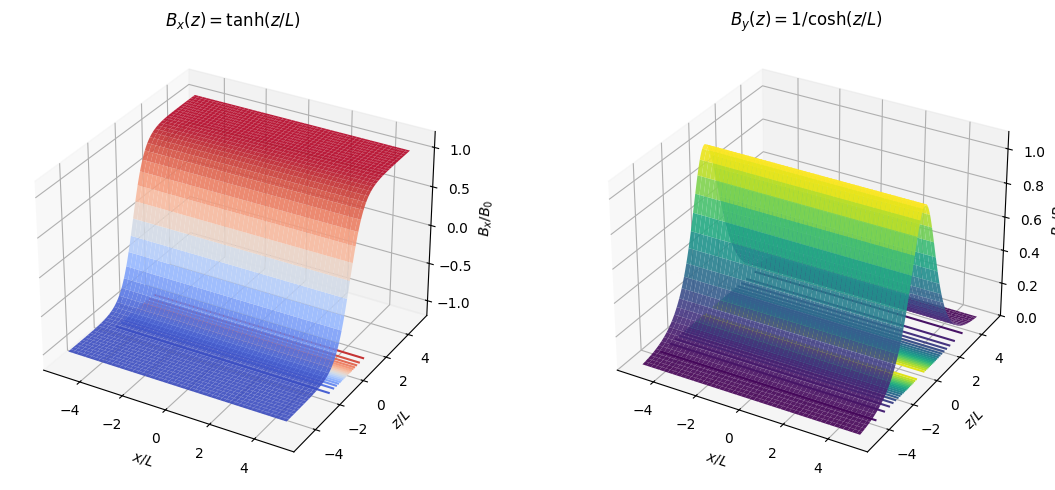

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grid in x-z plane
x = np.linspace(-5, 5, 200)
z = np.linspace(-5, 5, 200)
X, Z = np.meshgrid(x, z)

# Magnetic fields (normalized by B0)
Bx = np.tanh(Z)
By = 1 / np.cosh(Z)

fig = plt.figure(figsize=(12,5))

# ---------------- Bx ----------------
ax1 = fig.add_subplot(121, projection='3d')

surf1 = ax1.plot_surface(X, Z, Bx,
                         cmap='coolwarm',
                         edgecolor='none',
                         alpha=0.9)

ax1.set_xlabel(r'$x/L$')
ax1.set_ylabel(r'$z/L$')
ax1.set_zlabel(r'$B_x/B_0$')
ax1.set_title(r'$B_x(z)=\tanh(z/L)$')

# contour projected on bottom plane
ax1.contour(X, Z, Bx, zdir='z', offset=-1.2,
            cmap='coolwarm', levels=20)

ax1.set_zlim(-1.2, 1.2)

# ---------------- By ----------------
ax2 = fig.add_subplot(122, projection='3d')

surf2 = ax2.plot_surface(X, Z, By,
                         cmap='viridis',
                         edgecolor='none',
                         alpha=0.9)

ax2.set_xlabel(r'$x/L$')
ax2.set_ylabel(r'$z/L$')
ax2.set_zlabel(r'$B_y/B_0$')
ax2.set_title(r'$B_y(z)=1/\cosh(z/L)$')

ax2.contour(X, Z, By, zdir='z', offset=0,
            cmap='viridis', levels=20)

ax2.set_zlim(0, 1.1)

plt.tight_layout()
plt.show()

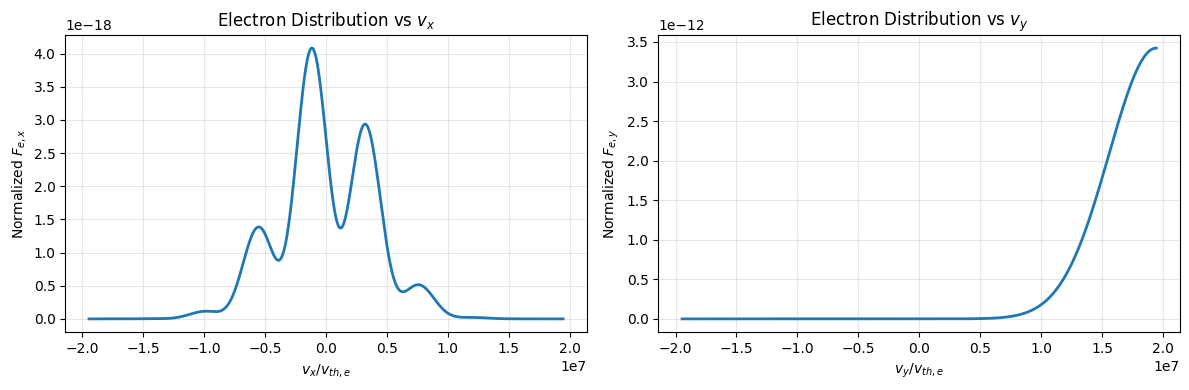

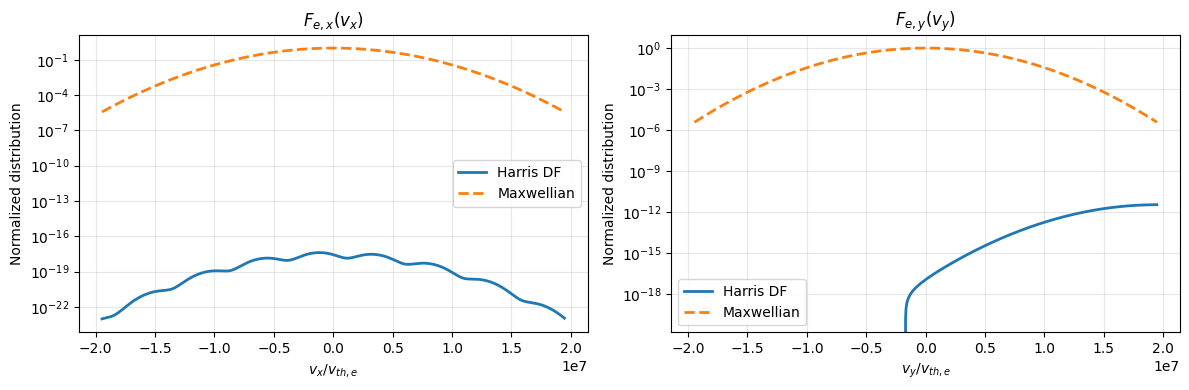

Rx(z) = 269067.1690668455
Ry(z) = 4023440325187.9834


NameError: name 'j0_i' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Constants
# --------------------------------------------------
kB = 1.38e-23
me = 9.11e-31
qe = -1.60e-19

# --------------------------------------------------
# Plasma parameters
# --------------------------------------------------
Te = 1.0e6              # K
beta = 1.0 / (kB * Te)
vth = np.sqrt(1.0 / (me * beta))

n0 = 1.0
b = 100
u0 = 5 * vth

# --------------------------------------------------
# Magnetic configuration
# --------------------------------------------------
B0 = 5e-6
L  = 1.0
z  = 2.0 * L
phi = 0.0

Ax = B0 * L * np.arctan(np.sinh(z / L))
Ay = -B0 * L * np.log(np.cosh(z / L))

# --------------------------------------------------
# Velocity grid
# --------------------------------------------------
v = np.linspace(-5*vth, 5*vth, 1000)

# ==================================================
# Electron DF in x-direction
# Set vy = vz = 0
# ==================================================
vx = v
vy = 0.0
vz = 0.0

# Hamiltonian
He_x = 0.5 * me * (vx**2 + vy**2 + vz**2) + qe * phi

# Canonical momentum px
px = me * vx + qe * Ax

# Electron DF depending only on vx
Fe_x = (
    n0 / ((1 + b) * (np.sqrt(2*np.pi) * vth)**3)
    * np.exp(-beta * He_x)
    * (
        b
        - 0.5 * np.exp(beta * me * u0**2 / 2.0)
          * np.cos(beta * u0 * px)
        + np.exp(beta * me * u0**2 / 2.0)
    )
)


# ==================================================
# Electron DF in y-direction
# Set vx = vz = 0
# ==================================================
vx = 0.0
vy = v
vz = 0.0

# Hamiltonian
He_y = 0.5 * me * (vx**2 + vy**2 + vz**2) + qe * phi

# Canonical momentum py
py = me * vy + qe * Ay

# Electron DF depending only on vy
Fe_y = (
    n0 / ((1 + b) * (np.sqrt(2*np.pi) * vth)**3)
    * np.exp(-beta * He_y)
    * (
        b
        - 0.5 * np.exp(beta * me * u0**2 / 2.0)
        + np.exp(beta * me * u0**2 / 2.0)
          * np.exp(beta * u0 * py)
    )
)




# ==================================================
# Plot
# ==================================================
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(v, Fe_x, lw=2)
ax[0].set_xlabel(r'$v_x/v_{th,e}$')
ax[0].set_ylabel(r'Normalized $F_{e,x}$')
ax[0].set_title(r'Electron Distribution vs $v_x$')
ax[0].grid(alpha=0.3)

ax[1].plot(v, Fe_y, lw=2)
ax[1].set_xlabel(r'$v_y/v_{th,e}$')
ax[1].set_ylabel(r'Normalized $F_{e,y}$')
ax[1].set_title(r'Electron Distribution vs $v_y$')
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Maxwellian distributions
# --------------------------------------------------

# define the velocity grids first
vx_grid = np.linspace(-5*vth, 5*vth, 1000)
vy_grid = np.linspace(-5*vth, 5*vth, 1000)

# Maxwellian distributions



FM_x = np.exp(-vx_grid**2 / (2*vth**2))
FM_y = np.exp(-vy_grid**2 / (2*vth**2))

FM_x = FM_x / np.max(FM_x)
FM_y = FM_y / np.max(FM_y)

# --------------------------------------------------
# Plot Harris DF and Maxwellian together
# --------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12,4))

ax[0].plot(vx_grid, Fe_x, lw=2, label='Harris DF')
ax[0].plot(vx_grid, FM_x, '--', lw=2, label='Maxwellian')
ax[0].set_xlabel(r'$v_x/v_{th,e}$')
ax[0].set_ylabel('Normalized distribution')
ax[0].set_title(r'$F_{e,x}(v_x)$')
ax[0].legend()
ax[0].grid(alpha=0.3)
ax[0].set_yscale("log")
ax[1].plot(vy_grid, Fe_y, lw=2, label='Harris DF')
ax[1].plot(vy_grid, FM_y, '--', lw=2, label='Maxwellian')
ax[1].set_xlabel(r'$v_y/v_{th,e}$')
ax[1].set_ylabel('Normalized distribution')
ax[1].set_title(r'$F_{e,y}(v_y)$')
ax[1].legend()
ax[1].grid(alpha=0.3)
ax[1].set_yscale("log")
plt.tight_layout()
plt.show()

from scipy.integrate import simpson

# Use only positive velocities for collected current
vpos = np.linspace(0, 10*vth, 2000)

# ---------- x direction ----------
px = me*vpos + qe*Ax

Fe_x_pos = np.exp(-vpos**2/(2*vth**2)) * (
    b
    - 0.5*np.exp(beta*me*u0**2/2.0)*np.cos(beta*u0*px)
    + np.exp(beta*me*u0**2/2.0)
)

FM_x_pos = np.exp(-vpos**2/(2*vth**2))

jx_e = simpson(qe * vpos * Fe_x_pos, x=vpos)
jx_M = simpson(qe * vpos * FM_x_pos, x=vpos)

Rx = jx_e / jx_M

# ---------- y direction ----------
py = me*vpos + qe*Ay

Fe_y_pos = np.exp(-vpos**2/(2*vth**2)) * (
    b
    - 0.5*np.exp(beta*me*u0**2/2.0)
    + np.exp(beta*me*u0**2/2.0) * np.exp(beta*u0*py)
)

FM_y_pos = np.exp(-vpos**2/(2*vth**2))

jy_e = simpson(qe * vpos * Fe_y_pos, x=vpos)
jy_M = simpson(qe * vpos * FM_y_pos, x=vpos)

Ry = jy_e / jy_M

print("Rx(z) =", Rx)
print("Ry(z) =", Ry)





# For a negatively charged spacecraft, ions are attracted:
jx_i_V = j0_i * (1 + qi * V / (kB * Te))
jy_i_V = j0_i * (1 + qi * V / (kB * Te))

# Net current density in x and y directions

jx_net_V = jx_i_V - jx_e_V
jy_net_V = jy_i_V - jy_e_V

# Magnitude of the total net current density
jtotal_V = np.sqrt(jx_net_V**2 + jy_net_V**2)

# --------------------------------------------------
# Solve dV/dt = Jtotal(V) * A / C
# --------------------------------------------------

# spacecraft parameters
A = 72        # m^2
C = 328.86e-12     # F

# --------------------------------------------------
# dV/dt function
# --------------------------------------------------
def dVdt(V):

    Vabs = np.abs(V)

    # avoid overflow in exponentials
    arg_e = np.clip(abs(qe) * Vabs / (kB * Te), 0, 50)
    arg_i = np.clip(abs(qe) * Vabs / (kB * Ti), 0, 50)

    # electron current density
    jx_e = Rx * j0_e * np.exp(-arg_e)
    jy_e = Ry * j0_e * np.exp(-arg_e)

    j_e_total = np.sqrt(jx_e**2 + jy_e**2)

    # ion current density
    jx_i = j0_i * (1 + arg_i)
    jy_i = j0_i * (1 + arg_i)

    j_i_total = np.sqrt(jx_i**2 + jy_i**2)

    # net current density
    jtotal = j_e_total - j_i_total

    return (A / C) * jtotal


# --------------------------------------------------
# Time array
# --------------------------------------------------
t = np.linspace(0, 10, 2000)
dt = t[1] - t[0]

# initial potential
V_t = np.zeros_like(t)
V_t[0] = 0.0

# --------------------------------------------------
# RK4 integration
# --------------------------------------------------
for i in range(1, len(t)):

    Vn = V_t[i-1]

    k1 = dVdt(Vn)
    k2 = dVdt(Vn + 0.5 * dt * k1)
    k3 = dVdt(Vn + 0.5 * dt * k2)
    k4 = dVdt(Vn + dt * k3)

    V_t[i] = Vn + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    # function returning dV/dt for RK4
def dVdt_func(V_now):

    Vabs = np.abs(V_now)

    # limit argument to avoid overflow
    arg_e = np.clip(abs(qe) * Vabs / (kB * Te), 0, 50)
    arg_i = np.clip(qi * Vabs / (kB * Te), 0, 50)

    # electron currents at current potential
    jx_e = Rx * j0_e * np.exp(-arg_e)
    jy_e = Ry * j0_e * np.exp(-arg_e)

    # ion currents at current potential
    jx_i = j0_i * (1 + arg_i)
    jy_i = j0_i * (1 + arg_i)

    # total electron current density magnitude
    j_e_total = np.sqrt(jx_e**2 + jy_e**2)

    # total ion current density magnitude
    j_i_total = np.sqrt(jx_i**2 + jy_i**2)

    # net total current density
    jtotal = j_e_total - j_i_total

    # return dV/dt
    return (A / C) * jtotal


# RK4 step
for i in range(1, len(t)):

    Vn = V_t[i-1]

    k1 = dVdt_func(Vn)
    k2 = dVdt_func(Vn + 0.5 * dt * k1)
    k3 = dVdt_func(Vn + 0.5 * dt * k2)
    k4 = dVdt_func(Vn + dt * k3)

    V_t[i] = Vn + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
# --------------------------------------------------
# Plot
# --------------------------------------------------
plt.figure(figsize=(7,5))
plt.plot(t,V_t, lw=2)
plt.xlabel('Time [s]')
plt.ylabel('Spacecraft Potential V [V]')
plt.title('Evolution of Spacecraft Potential')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

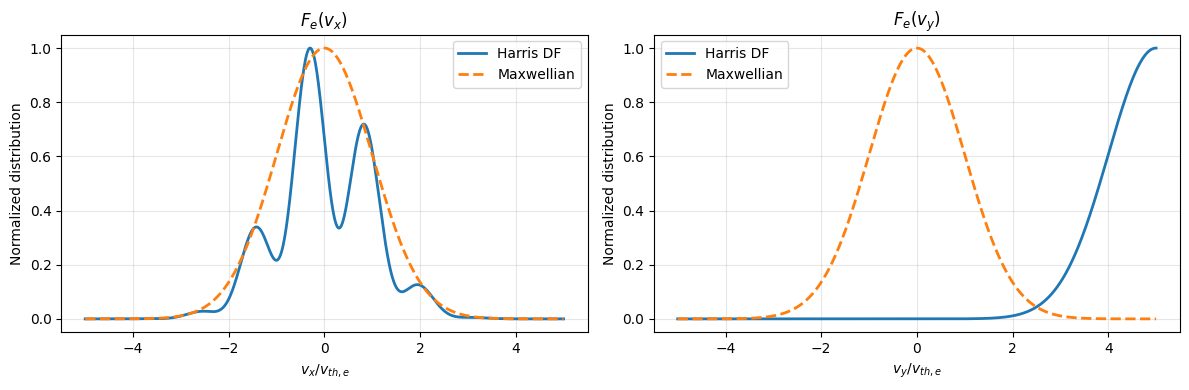

Electron current density jx_e = -0.6521408444630066
Electron current density jy_e = -9751653.389800128


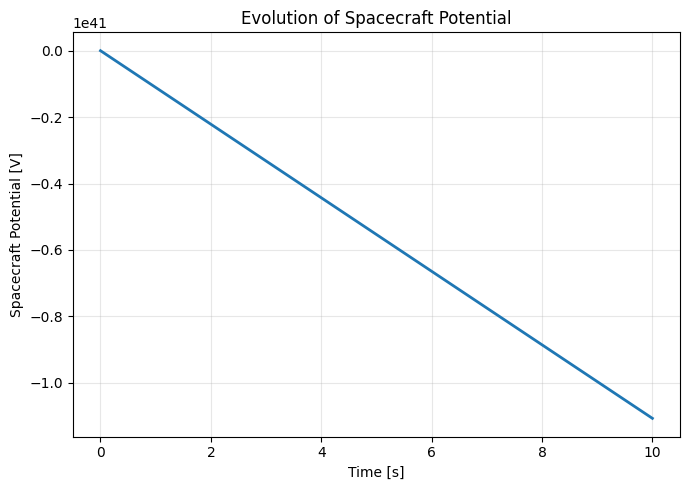

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# ==========================================================
# 1. Physical constants
# ==========================================================
kB = 1.38e-23          # Boltzmann constant [J/K]
me = 9.11e-31          # Electron mass [kg]
mi = 1.67e-27          # Ion mass [kg]
qe = -1.60e-19         # Electron charge [C]
qi = +1.60e-19         # Ion charge [C]

# ==========================================================
# 2. Plasma parameters
# ==========================================================
Te = 1.0e6             # Electron temperature [K]
Ti = 1.0e6             # Ion temperature [K]
n0 = 1.0e12            # Plasma density [m^-3]

# Thermal speeds
vth_e = np.sqrt(kB * Te / me)
vth_i = np.sqrt(kB * Ti / mi)

beta_e = 1.0 / (kB * Te)
beta_i = 1.0 / (kB * Ti)

# Harris-sheet parameters
b = 100
u0 = 5.0 * vth_e

# ==========================================================
# 3. Magnetic configuration of force-free Harris sheet
# ==========================================================
B0 = 5e-6              # Magnetic field [T]
L = 1.0                # Current sheet scale length [m]
z = 2.0 * L            # Position where DF is evaluated
phi = 0.0              # Spacecraft potential initially [V]

# Vector potentials
Ax = B0 * L * np.arctan(np.sinh(z / L))
Ay = -B0 * L * np.log(np.cosh(z / L))

# ==========================================================
# 4. Velocity grid
# ==========================================================
v = np.linspace(-5*vth_e, 5*vth_e, 1000)

# ==========================================================
# 5. Electron distribution in x-direction
# ==========================================================
px = me * v + qe * Ax

Fe_x = np.exp(-v**2 / (2*vth_e**2)) * (
    b
    - 0.5 * np.exp(beta_e * me * u0**2 / 2.0)
      * np.cos(beta_e * u0 * px)
    + np.exp(beta_e * me * u0**2 / 2.0)
)

# Normalize for shape comparison
Fe_x = Fe_x / np.max(Fe_x)

# ==========================================================
# 6. Electron distribution in y-direction
# ==========================================================
py = me * v + qe * Ay

Fe_y = np.exp(-v**2 / (2*vth_e**2)) * (
    b
    - 0.5 * np.exp(beta_e * me * u0**2 / 2.0)
    + np.exp(beta_e * me * u0**2 / 2.0)
      * np.exp(beta_e * u0 * py)
)

# Normalize
Fe_y = Fe_y / np.max(Fe_y)

# ==========================================================
# 7. Reference Maxwellian distributions
# ==========================================================
FM = np.exp(-v**2 / (2*vth_e**2))
FM = FM / np.max(FM)

# ==========================================================
# 8. Plot the Harris DF and Maxwellian
# ==========================================================
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(v / vth_e, Fe_x, lw=2, label='Harris DF')
ax[0].plot(v / vth_e, FM, '--', lw=2, label='Maxwellian')
ax[0].set_xlabel(r'$v_x/v_{th,e}$')
ax[0].set_ylabel('Normalized distribution')
ax[0].set_title(r'$F_e(v_x)$')
ax[0].legend()
ax[0].grid(alpha=0.3)

ax[1].plot(v / vth_e, Fe_y, lw=2, label='Harris DF')
ax[1].plot(v / vth_e, FM, '--', lw=2, label='Maxwellian')
ax[1].set_xlabel(r'$v_y/v_{th,e}$')
ax[1].set_ylabel('Normalized distribution')
ax[1].set_title(r'$F_e(v_y)$')
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# 9. Current density from the distribution function
# ==========================================================
# Only positive velocities contribute to collected current
vpos = np.linspace(0, 10*vth_e, 2000)

# x-direction current density
px_pos = me * vpos + qe * Ax

Fe_x_pos = np.exp(-vpos**2 / (2*vth_e**2)) * (
    b
    - 0.5 * np.exp(beta_e * me * u0**2 / 2.0)
      * np.cos(beta_e * u0 * px_pos)
    + np.exp(beta_e * me * u0**2 / 2.0)
)

jx_e = simpson(qe * vpos * Fe_x_pos, x=vpos)

# y-direction current density
py_pos = me * vpos + qe * Ay

Fe_y_pos = np.exp(-vpos**2 / (2*vth_e**2)) * (
    b
    - 0.5 * np.exp(beta_e * me * u0**2 / 2.0)
    + np.exp(beta_e * me * u0**2 / 2.0)
      * np.exp(beta_e * u0 * py_pos)
)

jy_e = simpson(qe * vpos * Fe_y_pos, x=vpos)

print('Electron current density jx_e =', jx_e)
print('Electron current density jy_e =', jy_e)

# ==========================================================
# 10. Reference ion current density
# ==========================================================
# Approximate thermal ion current density
j0_i = qi * n0 * np.sqrt(kB * Ti / (2 * np.pi * mi))

# Approximate thermal electron current density
j0_e = abs(qe) * n0 * np.sqrt(kB * Te / (2 * np.pi * me))

# Ratio between Harris and Maxwellian collection current
Rx = abs(jx_e) / j0_e
Ry = abs(jy_e) / j0_e

# ==========================================================
# 11. Spacecraft and capacitance parameters
# ==========================================================
A = 72.0               # Effective collection area [m^2]
C = 328.86e-12         # Spacecraft capacitance [F]

# ==========================================================
# 12. Differential equation for spacecraft potential
# ==========================================================
# I want to also insert the secondary electron current density emission effect in this current model
E_max = 0.25      # keV
delta_max = 0.92
A_sey = 0.1460
B_sey = 0.0250
C_sey = 0.3440
def dVdt(V):

    # dimensionless potential factors
    arg_e = qe * V / (kB * Te)
    arg_i = qi * V / (kB * Ti)

    # prevent overflow in exponential
    arg_e = np.clip(arg_e, -50, 50)
    arg_i = np.clip(arg_i, -50, 50)

    # electron current density
    jx_e_V = Rx * j0_e * np.exp(arg_e)
    jy_e_V = Ry * j0_e * np.exp(arg_e)

    # ion current density
    jx_i_V = j0_i * (1 - arg_i)
    jy_i_V = j0_i * (1 - arg_i)

    # prevent ion current becoming negative
    jx_i_V = max(jx_i_V, 0.0)
    jy_i_V = max(jy_i_V, 0.0)

    # total current magnitudes
    j_e_total = np.sqrt(jx_e_V**2 + jy_e_V**2)
    j_i_total = np.sqrt(jx_i_V**2 + jy_i_V**2)

    # net current density
    j_net = j_i_total - j_e_total

    return (A / C) * j_net


# ==========================================================
# 13. Time integration using RK4
# ==========================================================
t = np.linspace(0, 10, 3000)
dt = t[1] - t[0]

V = np.zeros_like(t)
V[0] = 0.0

for i in range(1, len(t)):

    Vn = V[i - 1]

    k1 = dVdt(Vn)
    k2 = dVdt(Vn + 0.5 * dt * k1)
    k3 = dVdt(Vn + 0.5 * dt * k2)
    k4 = dVdt(Vn + dt * k3)

    V[i] = Vn + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

# ==========================================================
# 14. Plot spacecraft potential versus time
# ==========================================================
plt.figure(figsize=(7,5))
plt.plot(t, V, lw=2)
plt.xlabel('Time [s]')
plt.ylabel('Spacecraft Potential [V]')
plt.title('Evolution of Spacecraft Potential')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


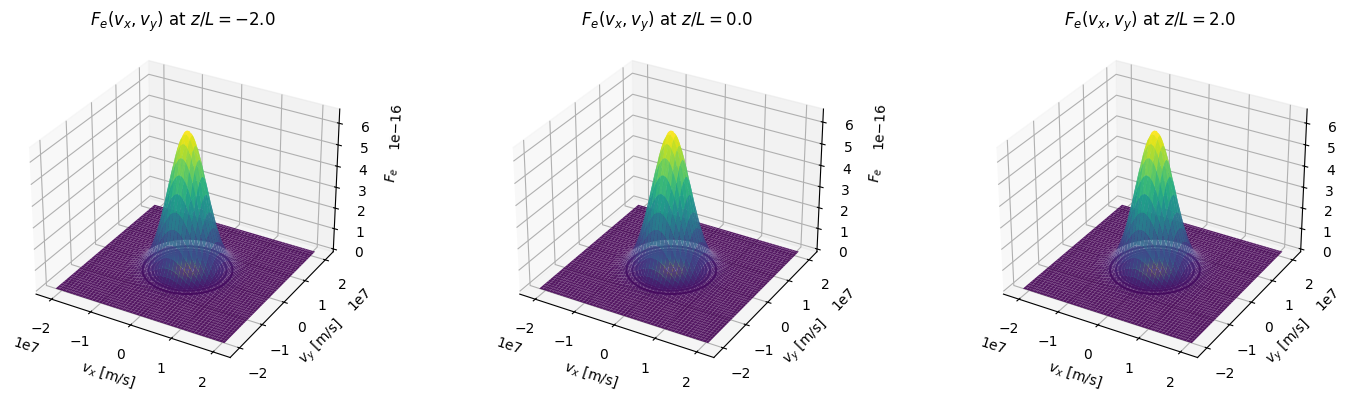

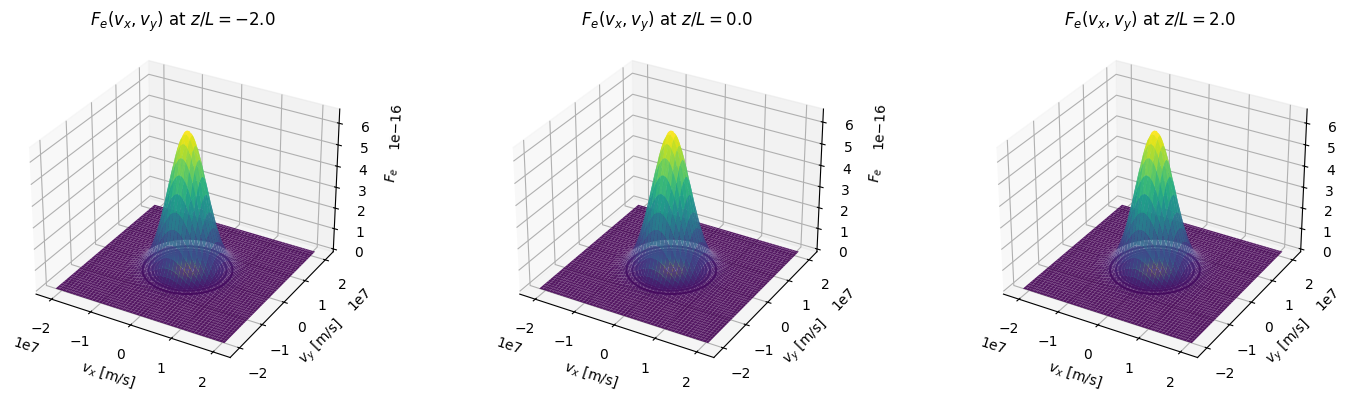

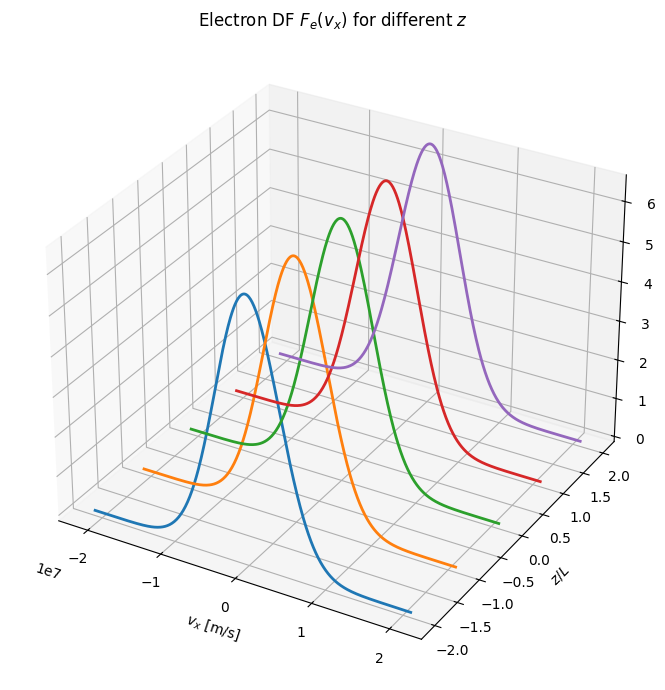

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Choose z positions across the current sheet
z_values = [-2*L, 0.0, 2*L]

# Velocity grid in vx-vy plane
vmax_e = 5 * thermal_speed(Te, me)
vx = np.linspace(-vmax_e, vmax_e, 150)
vy = np.linspace(-vmax_e, vmax_e, 150)
VX, VY = np.meshgrid(vx, vy)

# Fix vz = 0 for visualization
vz = 0.0

fig = plt.figure(figsize=(15, 4))

for i, z in enumerate(z_values):

    # Evaluate electron DF
    FE = F_e(VX, VY, vz, z, n0, Te, u0, b, B0, L)

    ax = fig.add_subplot(1, 3, i+1, projection='3d')

    surf = ax.plot_surface(
        VX, VY, FE,
        cmap='viridis',
        edgecolor='none',
        alpha=0.9
    )

    # Project contours onto bottom plane
    ax.contour(VX, VY, FE,
               zdir='z',
               offset=np.min(FE),
               levels=20,
               cmap='viridis')

    ax.set_xlabel(r'$v_x$ [m/s]')
    ax.set_ylabel(r'$v_y$ [m/s]')
    ax.set_zlabel(r'$F_e$')

    ax.set_title(rf'$F_e(v_x,v_y)$ at $z/L={z/L:.1f}$')

plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Choose z positions across the current sheet
z_values = [-2*L, 0.0, 2*L]

# Velocity grid in vx-vy plane
vmax_e = 5 * thermal_speed(Te, me)
vx = np.linspace(-vmax_e, vmax_e, 150)
vy = np.linspace(-vmax_e, vmax_e, 150)
VX, VY = np.meshgrid(vx, vy)

# Fix vz = 0 for visualization
vz = 0.0

fig = plt.figure(figsize=(15, 4))

for i, z in enumerate(z_values):

    # Evaluate electron DF
    FE = F_e(VX, VY, vz, z, n0, Te, u0, b, B0, L)

    ax = fig.add_subplot(1, 3, i+1, projection='3d')

    surf = ax.plot_surface(
        VX, VY, FE,
        cmap='viridis',
        edgecolor='none',
        alpha=0.9
    )

    # Project contours onto bottom plane
    ax.contour(VX, VY, FE,
               zdir='z',
               offset=np.min(FE),
               levels=20,
               cmap='viridis')

    ax.set_xlabel(r'$v_x$ [m/s]')
    ax.set_ylabel(r'$v_y$ [m/s]')
    ax.set_zlabel(r'$F_e$')

    ax.set_title(rf'$F_e(v_x,v_y)$ at $z/L={z/L:.1f}$')

plt.tight_layout()
plt.show()
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Values of z to compare
z_values = [-2*L, -L, 0.0, L, 2*L]

# Velocity range
vmax = 5 * thermal_speed(Te, me)
v = np.linspace(-vmax, vmax, 400)

# ---------- F_e(vx) for different z ----------
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

for i, z in enumerate(z_values):

    Fe_vx = F_e(v, 0.0, 0.0, z, n0, Te, u0, b, B0, L)

    # y-axis is z/L to separate the curves
    zline = np.ones_like(v) * (z / L)

    ax.plot(v, zline, Fe_vx, linewidth=2)

ax.set_xlabel(r'$v_x$ [m/s]')
ax.set_ylabel(r'$z/L$')
ax.set_zlabel(r'$F_e(v_x)$')
ax.set_title(r'Electron DF $F_e(v_x)$ for different $z$')

plt.tight_layout()
plt.show()



In [ ]:
#To incorporate double maxwellian distribution

import numpy as np
import matplotlib.pyplot as plt

# Constants

e = 1.602e-19  #C
k = 1.38e-23    #SI
me = 9.11e-31     ##kg
mi = 1.67e-27      #kg
K = 1 / np.sqrt(2*np.pi)

# Spacecraft parameters
A = 72.0                      # m^2
C = 328.76e-12               # F

#electrons at T1 temperature

ne1 =
Te1_eV = 11989

#electrons at T2 temperature

ne2 = 0.25e6
Te2_eV = 9898

#ions

SyntaxError: invalid syntax (1128593754.py, line 20)

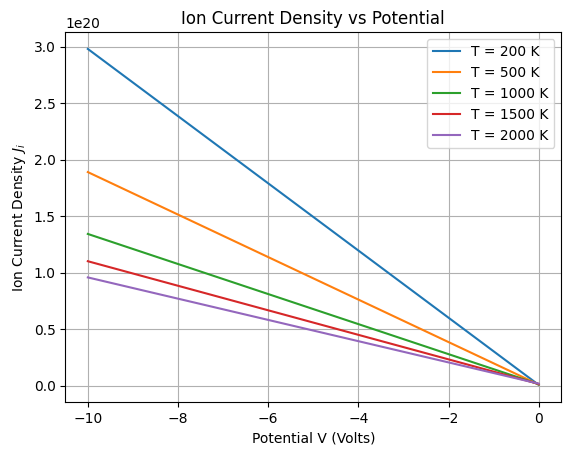

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

e = 1.602e-19
k = 1.381e-23
m = 1.67e-27
ne = 1e15

V = np.linspace(-10, 0, 500)
T = [200, 500, 1000, 1500, 2000]

plt.figure()

for t in T:
    J0i = (1/np.sqrt(2*np.pi)) * ne * np.sqrt((k*t)/m)
    Ji = J0i * (1 - (e*V)/(k*t))
    plt.plot(V, Ji, label=f"T = {t} K")

plt.xlabel("Potential V (Volts)")
plt.ylabel("Ion Current Density $J_i$")
plt.title("Ion Current Density vs Potential")
plt.legend()
plt.grid(True)

plt.show()

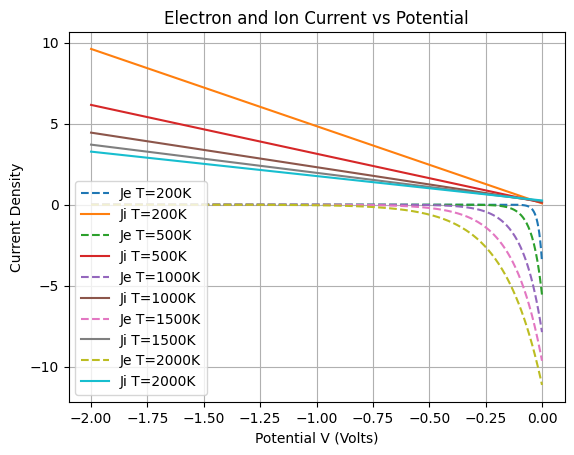

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

e = 1.602e-19
k = 1.381e-23

me = 9.11e-31
mi = 1.67e-27

ne = 1e15

V = np.linspace(-2,0,500)

T = [200,500,1000,1500,2000]

plt.figure()

for t in T:

    J0e = e*ne*np.sqrt((k*t)/(2*np.pi*me))
    J0i = e*ne*np.sqrt((k*t)/(2*np.pi*mi))

    Je = -J0e*np.exp((e*V)/(k*t))
    Ji = J0i*(1-(e*V)/(k*t))

    plt.plot(V,Je,'--',label=f"Je T={t}K")
    plt.plot(V,Ji,label=f"Ji T={t}K")

plt.xlabel("Potential V (Volts)")
plt.ylabel("Current Density")
plt.title("Electron and Ion Current vs Potential")
plt.legend()
plt.grid(True)

plt.show()

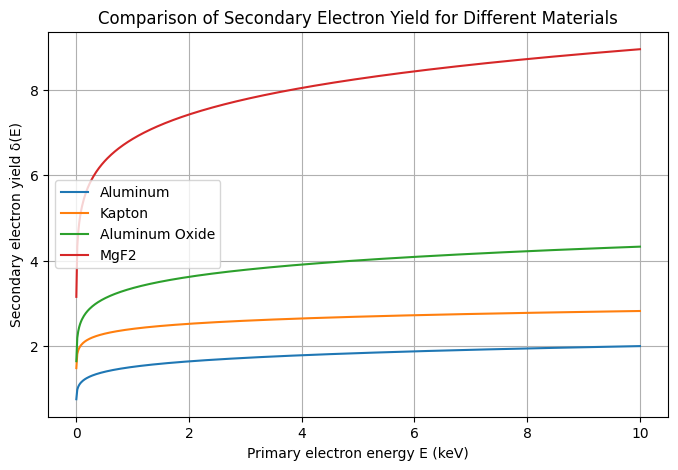

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Energy range (keV)
E = np.linspace(0.001, 10, 600)

# Material database
# name : (E_max, delta_max, A, B, C)
materials = {
    "Aluminum":        (0.30, 0.97, 0.1568, 0.0303, 0.3431),
    "Kapton":          (0.15, 2.10, 0.07,   0.0,    0.0),
    "Aluminum Oxide":  (0.30, 2.60, 0.1238, 0.01721,0.3435),
    "MgF2":           (0.85, 6.38, 0.1238,   0.0172, 0.3435),
}

# plot
plt.figure(figsize=(8,5))

for name, (E_max, delta_max, A, B, C) in materials.items():
    delta = delta_max * (E / E_max)**A * np.exp(
        A * (1 - (E / E_max)**B)
    ) + C
    plt.plot(E, delta, label=name)

plt.xlabel("Primary electron energy E (keV)")
plt.ylabel("Secondary electron yield δ(E)")
plt.title("Comparison of Secondary Electron Yield for Different Materials")
plt.legend()
plt.grid(True)

plt.show()

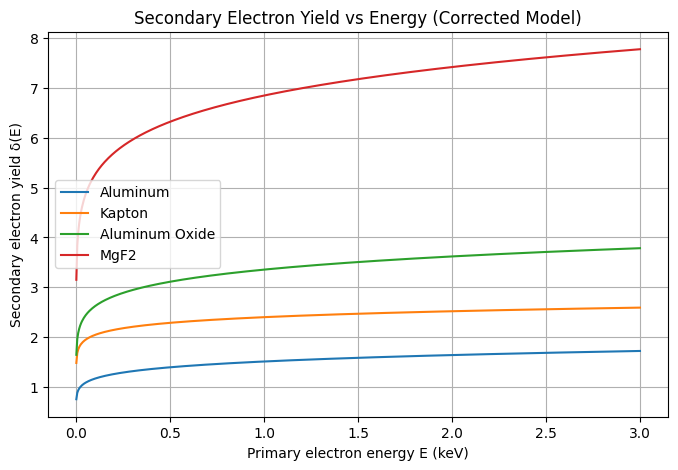

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Energy range (keV) ----------------
E = np.linspace(0.001, 3.0, 600)

# ---------------- Material database ----------------
# name : (E_max [keV], delta_max, A, B, C)
materials = {
    "Aluminum":        (0.30, 0.97, 0.1568, 0.0303, 0.3431),
    "Kapton":          (0.15, 2.10, 0.07,   0.0,    0.0),
    "Aluminum Oxide":  (0.30, 2.60, 0.1238, 0.01721,0.3435),
    "MgF2":            (0.85, 6.38, 0.1238, 0.0172, 0.3435),
}

# ---------------- Plot ----------------
plt.figure(figsize=(8,5))

for name, (Emax, dmax, A, B, C) in materials.items():

    x = E / Emax  # dimensionless energy ratio

    delta = dmax * (x**A) * np.exp(
        A * (1 - x**B)
    ) + C

    # prevent unphysical values below C
    delta = np.maximum(delta, C)

    plt.plot(E, delta, label=name)

# ---------------- Decorations ----------------
plt.xlabel("Primary electron energy E (keV)")
plt.ylabel("Secondary electron yield δ(E)")
plt.title("Secondary Electron Yield vs Energy (Corrected Model)")
plt.legend()
plt.grid(True)

plt.show()

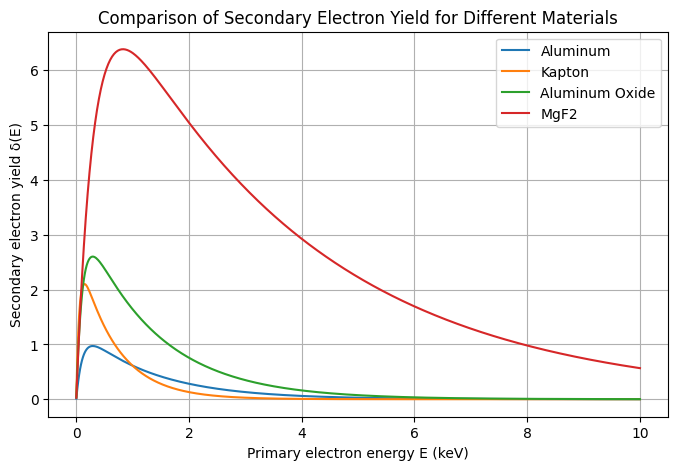

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Energy range (keV)
E = np.linspace(0.001, 10, 600)

# (E_max, delta_max)
materials = {
    "Aluminum":        (0.30, 0.97),
    "Kapton":          (0.15, 2.10),
    "Aluminum Oxide":  (0.30, 2.60),
    "MgF2":           (0.85, 6.38),
}

# plot
plt.figure(figsize=(8,5))

for name, (E_max, delta_max) in materials.items():
    delta = 1.37 * delta_max * (
    np.exp(-E / (4.3 * E_max))
    - np.exp(-E / (0.36 * E_max))
)
    plt.plot(E, delta, label=name)

plt.xlabel("Primary electron energy E (keV)")
plt.ylabel("Secondary electron yield δ(E)")
plt.title("Comparison of Secondary Electron Yield for Different Materials")
plt.legend()
plt.grid(True)

plt.show()